# Classification task with CWT and CNN model

This model is based on ["Real-Time Stress Detection via Photoplethysmogram Signals: Implementation of a Combined Continuous Wavelet Transform and Convolutional Neural Network on Resource-Constrained Microcontrollers"](https://ieeexplore.ieee.org/document/10668302) 

In [1]:
%matplotlib widget
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
import random
from IPython.display import display
from dataclasses import dataclass
from typing import Tuple, TypeAlias

from tensorflow import keras
from keras import layers, models, Input
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

from scipy.signal import resample
from skimage.transform import resize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, LeaveOneOut, GroupKFold, StratifiedKFold, KFold

DATASET = "../../stressid-dataset/Physiological"
LABELS_SEPARATOR = ","
LABELS = "../labels.csv"
DATA_SEPARATOR = ","
DATA_ECG = f"{DATASET}/ecg_windowed.csv"
DATA_EDA = f"{DATASET}/eda_windowed.csv"
DATA_FS = 500 # Hz
DATA_WINDOW_DURATION = 60 # seconds
TARGET_FS = 51.2
RANDOM_STATE = 21

# Training parameters
HOLDOUT_ITERATIONS = 10
HOLDOUT_TEST_PROPORTION = 0.2
KF_N_FOLDS = 5

LABELS_CONF = {
    "b": {
        "col_name": "binary-stress",
        "enabled": True,
        "stratification": True,
    },
    "t": {
        "col_name": "affect3-class",
        "enabled": False,
        "stratification": True,
    },
    "q": {
        "col_name": "affect4-class",
        "enabled": False,
        "stratification": True,
    },
}

BIN_LABELS = ["NoStress", "Stress"]
TER_LABELS = ["Relaxed", "Stress", "RealStress"]
QAD_LABELS = ["Relaxed", "Stress", "RealStress", "Amused"]

@dataclass
class Dataset:
    X: list[pd.Series]
    y: pd.Series
    groups: np.ndarray[int]

CWT: TypeAlias = Tuple[np.ndarray[tuple[int], np.dtype], np.ndarray]


### Creating test and train images

In [2]:
# Creating labels object

labels_df = pd.read_csv(LABELS, sep=LABELS_SEPARATOR, header=0, index_col=0)
labels: dict[str, pd.Series] = {}
for key, conf in LABELS_CONF.items():
    if conf["enabled"]:
        labels[key] = labels_df[conf["col_name"]]

display(labels['b'])

subject/task
2ea4_Breathing    0
2ea4_Counting1    1
2ea4_Counting2    1
2ea4_Counting3    1
2ea4_Math         1
                 ..
y9z6_Relax        0
y9z6_Speaking     1
y9z6_Stroop       1
y9z6_Video1       1
y9z6_Video2       0
Name: binary-stress, Length: 700, dtype: int64

In [3]:
# Pairing labels and samples for each class type

raw_num_samples = DATA_FS * DATA_WINDOW_DURATION
raw_df = pd.read_csv(DATA_EDA)

datasets: dict[str, Dataset] = {}
for class_type, labels_set in labels.items():
    subject_to_group: dict[str, int] = {}
    group_counter = 0
    samples: list[pd.Series] = []
    groups_list: list[int] = []
    for col_name, label in labels_set.items():
        subject_id = col_name.split("_")[0]
        if subject_id not in subject_to_group:
            subject_to_group[subject_id] = group_counter
            group_counter += 1
        if col_name in raw_df.columns:
            samples.append(raw_df[col_name])
        groups_list.append(subject_to_group[subject_id])
    groups = np.array(groups_list)
    datasets[class_type] = Dataset(samples, labels_set, groups)
    print(f"Class type: {class_type}. Saving {len(datasets[class_type].X)} samples with {len(datasets[class_type].y)} labels")
    print(f"{len(subject_to_group)} groups found. Indexed {len(groups)}.")

Class type: b. Saving 699 samples with 700 labels
64 groups found. Indexed 700.


In [4]:
#display(datasets['b'].groups)
#display(datasets["b"].X)
#display(datasets['b'].y)

### Preprocessing functions

For window length: 10s
The samples per window if 64Hz would be 640 (64 x 10)
Consider 1 second stride as paper: stride samples would be 64

Maintaining the same window length of 10 seconds
Training dataset @500Hz: window(5000 samples), stride(500 samples)
Experiment unseen data @51.2Hz: window(512 samples), stride(51 samples)

To maintain the same image resolution
* a) Data could be downsampled 500Hz->100Hz or upsampled 51.2Hz->100Hz to achieve consistent 640 samples per window
* b) CWT generated images could be resized to a common resolution

In [5]:
def segment_signal(
    signal: np.ndarray, fs: float, window_size_sec: float = 10, stride_sec: float = 1, target_fs: float | None = None
) -> np.ndarray:
    num_samples = len(signal)
    if target_fs and target_fs != fs:
        target_num_samples = int(num_samples * target_fs / fs)
        signal = resample(signal, target_num_samples)
        fs = target_fs
        num_samples = len(signal)

    window_size = int(window_size_sec * fs)
    stride_size = int(stride_sec * fs)
    segments = []
    end_idx = num_samples - window_size
    end_idx = 1 if end_idx < 1 else end_idx # avoid empty result when sample size is the same as window size
    for start in range(0, end_idx, stride_size):
        segment = signal[start : start + window_size]
        segments.append(segment)
    return np.array(segments)


def cwt_transform(
    signal: np.ndarray, wavelet="cmor1.5-1.0", fs: float = TARGET_FS, freq_band: Tuple[float, float] = (0.5, 50.0), n_bins: int=100
) -> CWT:
    dt = 1.0 / fs
    fmin, fmax = freq_band
    freqs = np.linspace(fmin, fmax, num=n_bins)
    scales = pywt.central_frequency(wavelet) / (freqs * dt)
    coefficients, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=dt)
    return np.abs(coefficients) ** 2, freqs


def create_cwt_images(segments: list[np.ndarray], img_size: tuple[int, int] = (128, 128)) -> list[CWT]:
    images: list[CWT] = []
    for seg in segments:
        cwt_img, freqs = cwt_transform(seg)
        cwt_img_resized = resize(cwt_img, img_size, anti_aliasing=True)
        images.append((cwt_img_resized, freqs))
    return images


datagen = ImageDataGenerator(
    rescale=1.0 / 255, rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True
)

### CNN Model

In [6]:
def build_model(input_shape):
    model = Sequential(
        [
            Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
            MaxPooling2D((2, 2)),
            Conv2D(64, (3, 3), activation="relu"),
            MaxPooling2D((2, 2)),
            Flatten(),
            Dense(128, activation="relu"),
            Dense(2, activation="softmax"),  # stress vs non-stress
        ]
    )
    model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# Suppose you have: X_train (N, H, W), y_train
# Expand dims for channels
# X_train = np.expand_dims(X_train, -1)

# model = build_model(input_shape=(H, W, 1))
# history = model.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=5)

def build_onehead_cnn(eda_shape, num_classes=2):
    """
    One-head CNN for stress classification using only EDA CWT images.

    Parameters
    ----------
    eda_shape : tuple
        Shape of EDA spectrogram input (time, freq, 1).
    num_classes : int
        Number of output classes (e.g., 2 = stressed vs non-stressed).
    """

    # Input: CWT spectrogram (image)
    eda_input = Input(shape=eda_shape, name="eda_input")

    # Convolutional feature extractor
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(eda_input)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)  # summarize spatial features

    # Fully connected classifier
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(num_classes, activation="softmax")(x)

    # Model
    model = models.Model(inputs=eda_input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

### Training and Validation (GroupKFold)

CWTs for "b" classes
Using 5 samples


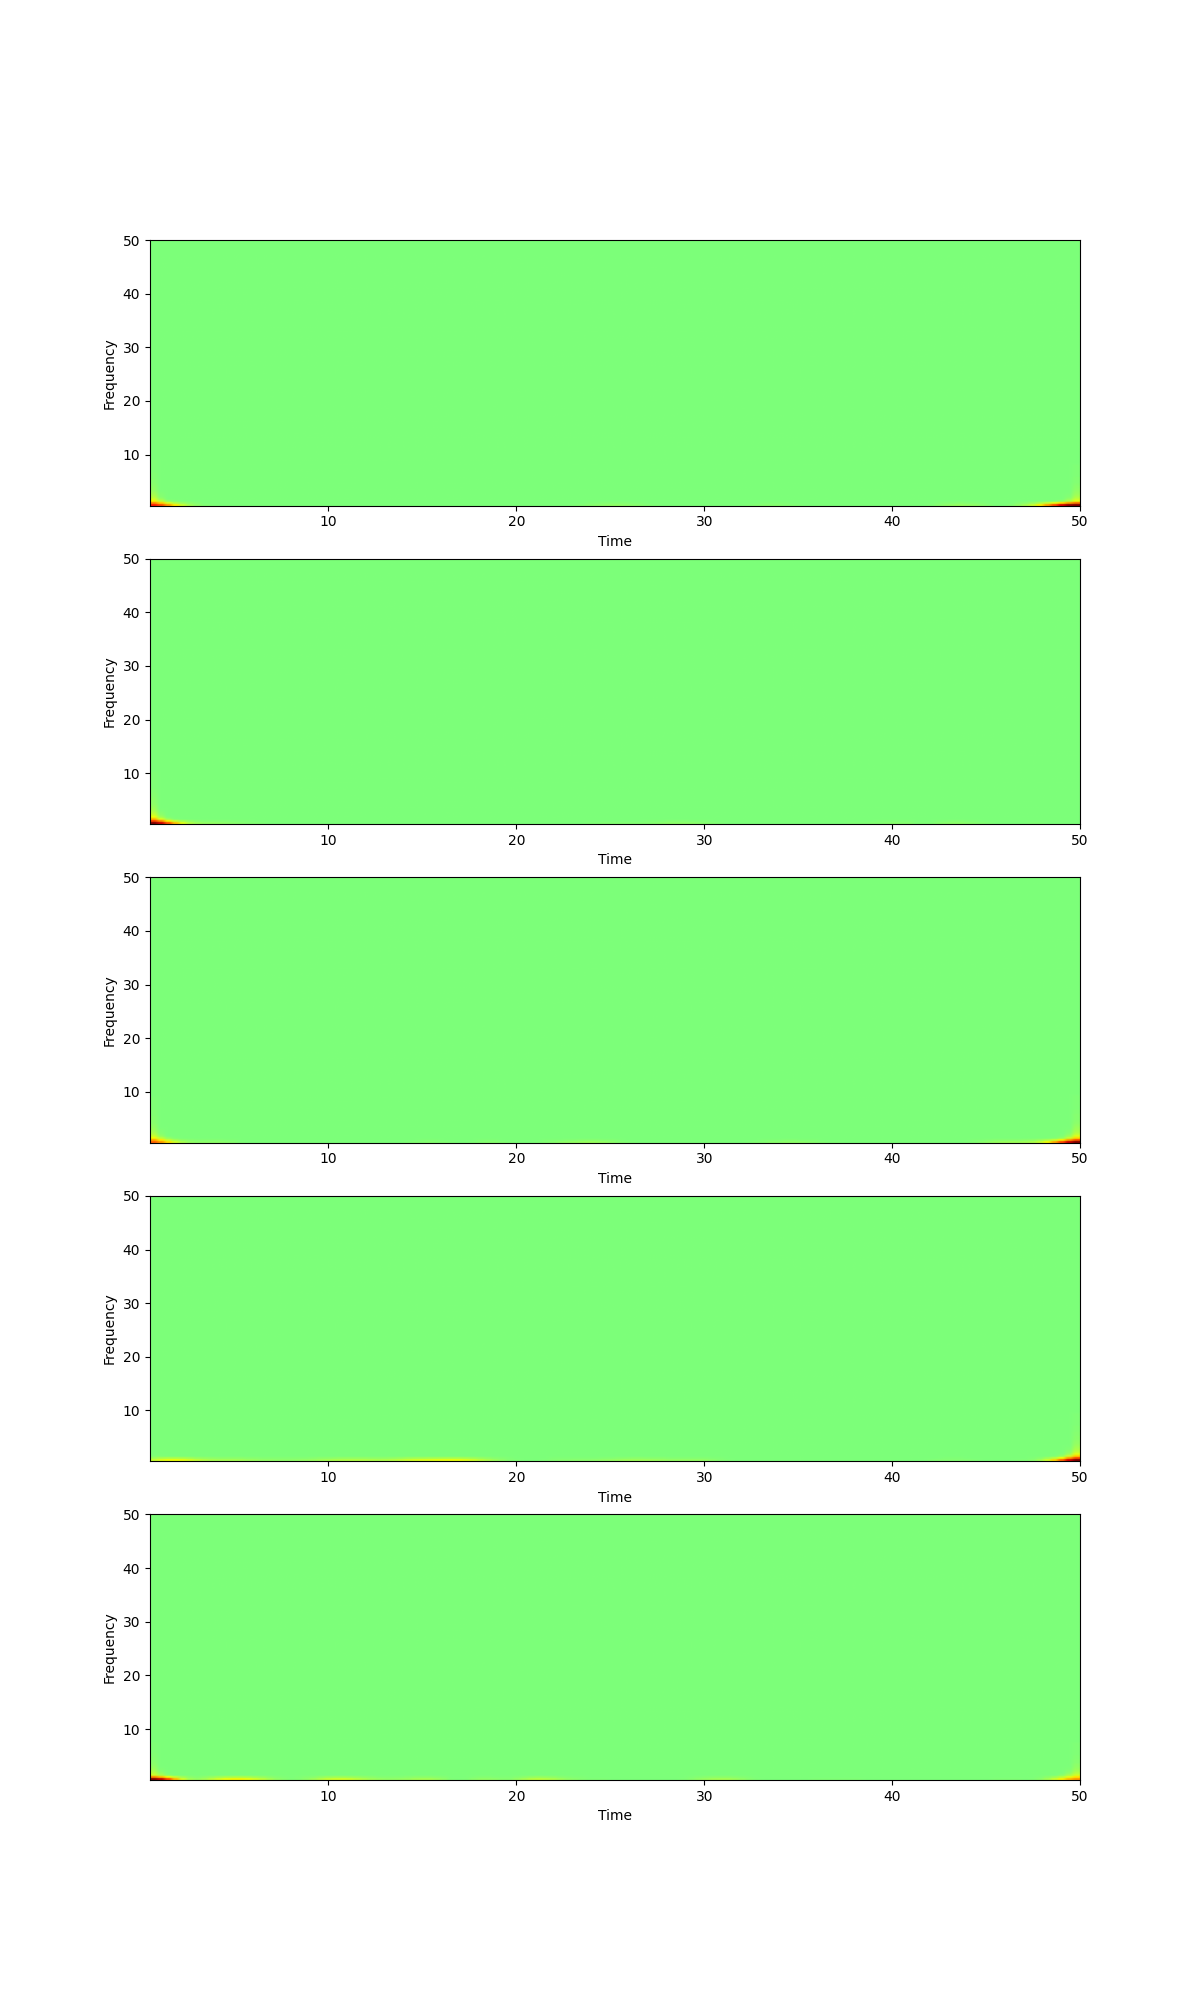

In [7]:
# Create CWT images
CWT_SHOW = True
RESAMPLING_SHOW = False
SHOW_N_SAMPLES = 5
SHOW_NROWS = (SHOW_N_SAMPLES * 1 if CWT_SHOW else 0) + (SHOW_N_SAMPLES * 2 if RESAMPLING_SHOW else 0)
SHOWS_NCOLS = 1
FIGSIZE = (12, 4 * SHOW_NROWS)
if RESAMPLING_SHOW or CWT_SHOW:
    fig, axes = plt.subplots(SHOW_NROWS, SHOWS_NCOLS, figsize=FIGSIZE)

dt = 1.0 / TARGET_FS
fmin, fmax = (0.5, 50.0)
freqs = np.linspace(fmin, fmax, num=100)
scales = pywt.central_frequency("cmor1.5-1.0") / (freqs * dt)

X = {}
ax_counter = 0
for class_type, dataset in datasets.items():
    print(f'CWTs for "{class_type}" classes')
    cwts_list: list[np.ndarray[tuple[int], np.dtype]] = []
    i = 0
    for sample in dataset.X:
        sample_name = dataset.y.index[i]
        segments = segment_signal(
            sample.to_numpy(),
            fs=DATA_FS,
            window_size_sec=DATA_WINDOW_DURATION,
            stride_sec=DATA_WINDOW_DURATION,
            target_fs=TARGET_FS,
        )
        if RESAMPLING_SHOW:
            axes[ax_counter].set_title(f"Original {sample_name}")
            axes[ax_counter].plot(sample, label=f"Original ({DATA_FS}Hz)")
            #axes[ax_counter].set_ylabel("Sample")
            #axes[ax_counter].set_xlabel("Amplitude")
            ax_counter += 1
            axes[ax_counter].set_title("Resampled signal")
            axes[ax_counter].plot(segments[0], label=f"Resampled ({TARGET_FS}Hz)")
            #axes[ax_counter].set_ylabel("Sample")
            #axes[ax_counter].set_xlabel("Amplitude")
            ax_counter += 1

        cwts = create_cwt_images(segments)
        cwt, cwt_freqs = cwts[0]
        cwts_list.append(cwt)

        if CWT_SHOW:
            norm_cwt = cwt / np.max(cwt)
            axes[ax_counter].imshow(
                norm_cwt,
                extent=[freqs.min(), freqs.max(), cwt_freqs.min(), cwt_freqs.max()],
                cmap="jet",
                aspect="auto",
                origin="lower",
                vmax=abs(norm_cwt.max()),
                vmin=-abs(norm_cwt.max()),
            )
            #axes[ax_counter].set_colorbar(label="Power")
            axes[ax_counter].set_ylabel("Frequency")
            axes[ax_counter].set_xlabel("Time")
            ax_counter += 1

        i += 1
        if (RESAMPLING_SHOW or CWT_SHOW) and (i+1) > SHOW_N_SAMPLES:
            break

    print(f"Using {len(cwts_list)} samples")
    X[class_type] = np.array(cwts_list)

In [8]:
# Group K-fold training and validation

for class_type, dataset in datasets.items():
    X_cwts = X[class_type]
    print(f"Training for \"{class_type}\" classes")

    stratify = LABELS_CONF[class_type]["stratification"]
    df_res = pd.DataFrame({"n": [], "f1-score": [], "accuracy": [], "classifier": [], "time": []})
    conf_matrices: dict[str, np.ndarray] = {}

    results = []
    gkf = GroupKFold(n_splits=KF_N_FOLDS)
    for i, (train_idxs, test_idxs) in enumerate(gkf.split(X_cwts, dataset.y, dataset.groups)):
        print(f"Group fold {i+1:2d}/{KF_N_FOLDS:2d}")
        X_train = X_cwts[train_idxs]
        y_train = dataset.y[train_idxs]
        X_test = X_cwts[test_idxs]
        y_test = dataset.y[test_idxs]
        # adding extra dimension for CNN
        X_train = np.expand_dims(X_train, -1)
        X_test = np.expand_dims(X_test, -1)
        # normalization
        X_train = X_train / np.max(X_train)
        X_test = X_test / np.max(X_test)

        model = build_model(input_shape=X_train.shape[1:])
        if i == 0:
            display(model.summary())

        train_generator = datagen.flow(X_train, y_train, batch_size=32)
        steps = train_generator.n // train_generator.batch_size
        model.fit(
            train_generator,
            steps_per_epoch=steps,
            epochs=10,
            validation_data=(X_test, y_test)
        )
        acc = model.evaluate(X_test, y_test, verbose=0)[1]
        results.append(acc)

    # for n_iter in range(HOLDOUT_ITERATIONS):
    #    int_state = random.randint(0, 1000000)
    #    x_train, x_test, y_train, y_test = train_test_split(
    #        X_cwts, dataset.y, test_size=HOLDOUT_TEST_PROPORTION, random_state=int_state, stratify=stratify
    #    )
    #    print("Random Split {0:2d}/{1:2d}".format(n_iter + 1, HOLDOUT_ITERATIONS))

    print(f"GroupKFold accuracies per subject: {results}")
    print(f"Mean acc: {np.mean(results):.3f} ± {np.std(results):.3f}")

Training for "b" classes


ValueError: Found input variables with inconsistent numbers of samples: [5, 700, 700]